#**<font color="green"> Monitoraggio della reputazione online di un’azienda </font>**
<a name="inizio" />

### **MachineInnovators Inc.**

REQUIREMENTS: MachineInnovators Inc. è leader nello sviluppo di applicazioni di machine learning scalabili e pronte per la produzione. Il focus principale del progetto è integrare metodologie MLOps per facilitare lo sviluppo, l'implementazione, il monitoraggio continuo e il retraining dei modelli di analisi del sentiment. L'obiettivo è abilitare l'azienda a migliorare e monitorare la reputazione sui social media attraverso l'analisi automatica dei sentiment.

Le aziende si trovano spesso a fronteggiare la sfida di gestire e migliorare la propria reputazione sui social media in modo efficace e tempestivo. Monitorare manualmente i sentiment degli utenti può essere inefficiente e soggetto a errori umani, mentre la necessità di rispondere rapidamente ai cambiamenti nel sentiment degli utenti è cruciale per mantenere un'immagine positiva dell'azienda.

Benefici della Soluzione

Automazione dell'Analisi del sentiment: Implementando un modello di analisi del sentiment basato su FastText, MLOps Innovators Inc. automatizzerà l'elaborazione dei dati dai social media per identificare sentiment positivi, neutrali e negativi. Ciò permetterà una risposta rapida e mirata ai feedback degli utenti.
Monitoraggio Continuo della Reputazione: Utilizzando metodologie MLOps, l'azienda implementerà un sistema di monitoraggio continuo per valutare l'andamento del sentiment degli utenti nel tempo. Questo consentirà di rilevare rapidamente cambiamenti nella percezione dell'azienda e di intervenire prontamente se necessario.
Retraining del Modello: Introdurre un sistema di retraining automatico per il modello di analisi del sentiment assicurerà che l'algoritmo si adatti dinamicamente ai nuovi dati e alle variazioni nel linguaggio e nei comportamenti degli utenti sui social media. Mantenere alta l'accuratezza predittiva del modello è essenziale per una valutazione corretta del sentiment.
Dettagli del Progetto

Fase 1: Implementazione del Modello di Analisi del sentiment con FastText
Modello: Utilizzare un modello pre-addestrato FastText per un’analisi del sentiment in grado di classificare testi dai social media in sentiment positivo, neutro o negativo. Servirsi di questo modello: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest
Dataset: Utilizzare dataset pubblici contenenti testi e le rispettive etichette di sentiment.
Fase 2: Creazione della Pipeline CI/CD
Pipeline CI/CD: Sviluppare una pipeline automatizzata per il training del modello, i test di integrazione e il deploy dell'applicazione su HuggingFace.
Fase 3: Deploy e Monitoraggio Continuo
Deploy su HuggingFace (facoltativo): Implementare il modello di analisi del sentiment, inclusi dati e applicazione, su HuggingFace per facilitare l'integrazione e la scalabilità.
Sistema di Monitoraggio: Configurare un sistema di monitoraggio per valutare continuamente le performance del modello e il sentiment rilevato.
Consegna
Codice Sorgente: Repository pubblica su GitHub con codice ben documentato per la pipeline CI/CD e l'implementazione del modello. La consegna vera e propria dovrà avvenire mediante un notebook google colab con al suo interno il link al repository GitHub.
Documentazione: Descrizione delle scelte progettuali, delle implementazioni e dei risultati ottenuti durante il progetto.
Motivazione del Progetto

L'implementazione di FastText per l'analisi del sentiment consente a MLOps Innovators Inc. di migliorare significativamente la gestione della reputazione sui social media. Automatizzando l'analisi del sentiment, l'azienda potrà rispondere più rapidamente alle esigenze degli utenti, migliorando la soddisfazione e rafforzando l'immagine dell'azienda sul mercato. Con questo progetto, MLOps Innovators Inc. promuove l'innovazione nel campo delle tecnologie AI, offrendo soluzioni avanzate e scalabili per le sfide moderne di gestione della reputazione aziendale.

**FASE 0: INSTALLAZIONE PACCHETTI PER OVVIARE INCOPATIBILITA' DI VERSIONI**

In [1]:
# Setup pulito e stabile (solo le librerie che servono)
!pip install -U \
    "numpy==1.26.4" \
    "pyarrow==14.0.2" \
    "pandas==2.2.2" \
    "transformers==4.44.2" \
    "datasets>=2.19" \
    "evaluate>=0.4" \
    "accelerate>=0.33" \
    "scikit-learn" \
    "gradio==4.*" \
    "huggingface_hub" \
    "fasttext" \
    "mlflow>=2.14"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 8.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━

In [1]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
import numpy, pyarrow, transformers, datasets
print("NumPy:", numpy.__version__)
print("PyArrow:", pyarrow.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

NumPy: 1.26.4
PyArrow: 14.0.2
Transformers: 4.44.2
Datasets: 2.19.2


**FASE 1: Configurazione & Token (Hugging Face)**

In [5]:
from huggingface_hub import login
import os

HF_TOKEN = os.getenv("HF_TOKEN")

if HF_TOKEN:
    # Non serve login() se la variabile d’ambiente è già attiva
    print("Variabile HF_TOKEN trovata: login Hugging Face già attivo.")
else:
    # In alternativa chiedi il token manualmente (solo se non impostato)
    from getpass import getpass
    HF_TOKEN = getpass("Inserisci il tuo token Hugging Face: ")
    os.environ["HF_TOKEN"] = HF_TOKEN
    login(token=HF_TOKEN, add_to_git_credential=True)
    print("Login completato.")


Variabile HF_TOKEN trovata: login Hugging Face già attivo.


**FASE 2: Caricamento Dataset TweetEval**

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("tweet_eval", "sentiment")
label_names = ds["train"].features["label"].names  # ['negative','neutral','positive']
print(label_names, ds)
pd.DataFrame(ds["train"][:5])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


['negative', 'neutral', 'positive'] DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [ ]:
print("Mappatura etichette:")
for i, label in enumerate(label_names):
    print(f"{i} → {label}")

Mappatura etichette:
0 → negative
1 → neutral
2 → positive


**FASE 3: Tokenizzazione e Preprocessing**

In [9]:
# =============================================
# FASE 3: TOKENIZZAZIONE E PREPROCESSING (corretta)
# =============================================

from transformers import AutoTokenizer
from datasets import load_dataset

# 1. Caricamento dataset
ds = load_dataset("tweet_eval", "sentiment")
print(ds)

label_names = ds["train"].features["label"].names
print("Etichette:", label_names)

# 2. Inizializzazione tokenizer
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 3. Tokenizzazione
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Applica la tokenizzazione ai tre split del dataset
tokenized_ds = ds.map(tokenize_fn, batched=True, remove_columns=["text"])

# Rinominare colonna "label" in "labels" per compatibilità con Hugging Face Trainer
tokenized_ds = tokenized_ds.rename_column("label", "labels")

# Imposta il formato PyTorch
tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# 4. Verifica struttura
print(tokenized_ds)
print("Esempio tokenizzato:")
print(tokenized_ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Etichette: ['negative', 'neutral', 'positive']


Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})
Esempio tokenizzato:
{'labels': tensor(2), 'input_ids': tensor([    0,   113,  1864,   565,   787, 12105,    96,     5,  1461,  2479,
            9,     5,   262,   212,  1040,     6,  8022,   687, 26110,   179,
         5601,     5,  9846,     9, 42210,     4,   849, 21136, 44728,  1208,
        31157,   687,   574,   658,   179,   113,     2,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,    

**FASE 4: VERIFICA TOKENIZZAZIONE**

In [11]:
# Preleva un esempio dal dataset tokenizzato
example = tokenized_ds["train"][0]

# Visualizza i primi token
print("Input IDs (primi 20):", example["input_ids"][:20].tolist())
print("Attention Mask (primi 20):", example["attention_mask"][:20].tolist())
print("Label numerica:", example["labels"])

# Mostra anche la label testuale corrispondente
label_names = ["negative", "neutral", "positive"]
print("Label testuale:", label_names[int(example["labels"])])

# Decodifica inversa per vedere il testo originale
decoded_text = tokenizer.decode(example["input_ids"], skip_special_tokens=True)
print("\nTesto decodificato:", decoded_text)

Input IDs (primi 20): [0, 113, 1864, 565, 787, 12105, 96, 5, 1461, 2479, 9, 5, 262, 212, 1040, 6, 8022, 687, 26110, 179]
Attention Mask (primi 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Label numerica: tensor(2)
Label testuale: positive

Testo decodificato: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"


**FASE 5: BASELINE FASTEXT**

In [12]:
import fasttext
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from datasets import load_dataset

# 1. Caricamento dataset TweetEval
ds = load_dataset("tweet_eval", "sentiment")

train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

label_names = ds["train"].features["label"].names
print("Mappatura etichette:", {i: label for i, label in enumerate(label_names)})

# 2. Salvataggio in formato FastText
def to_fasttext_format(df, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            # __label__<numero> <testo>
            label = f"__label__{row['label']}"
            text = row["text"].replace("\n", " ").replace("\t", " ")
            f.write(f"{label} {text}\n")

to_fasttext_format(train_df, "train.txt")
to_fasttext_format(test_df, "test.txt")

print("File FastText generati: train.txt e test.txt")

# 3. Addestramento modello FastText
model_ft = fasttext.train_supervised(
    input="train.txt",
    epoch=10,
    lr=1.0,
    wordNgrams=2,
    verbose=2
)

# 4. Predizione sul test set
preds = []
for text in test_df["text"]:
    label_pred = model_ft.predict(text.replace("\n", " "))[0][0]
    preds.append(int(label_pred.replace("__label__", "")))

y_true = test_df["label"]

# 5. Calcolo metriche
fasttext_acc = accuracy_score(y_true, preds)
fasttext_f1 = f1_score(y_true, preds, average="weighted")

print(f"FastText - Accuracy: {fasttext_acc:.4f}")
print(f"FastText - F1 Score: {fasttext_f1:.4f}")

# 6. Salvataggio dei risultati per confronto successivo
baseline_results = {
    "model": "FastText",
    "accuracy": fasttext_acc,
    "f1": fasttext_f1
}
print("\nRisultati baseline salvati:", baseline_results)

Mappatura etichette: {0: 'negative', 1: 'neutral', 2: 'positive'}
File FastText generati: train.txt e test.txt
FastText - Accuracy: 0.5613
FastText - F1 Score: 0.5444

Risultati baseline salvati: {'model': 'FastText', 'accuracy': 0.5612992510582872, 'f1': 0.5444163046611755}


**FASE 6: FINE-TUNING RoberTA**

In [13]:
import os
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import load_dataset
import numpy as np
import evaluate

os.environ["WANDB_DISABLED"] = "true"  # disattiva Weights & Biases (non necessario qui)

# Dataset: carica TweetEval e dividi in train/val/test
ds = load_dataset("tweet_eval", "sentiment")
train_ds = ds["train"]
val_ds = ds["validation"]
test_ds = ds["test"]

label_names = ds["train"].features["label"].names
print("Etichette:", label_names)

# Tokenizzazione
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

# Rinominare colonna "label" → "labels"
train_tok = train_tok.rename_column("label", "labels")
val_tok = val_tok.rename_column("label", "labels")
test_tok = test_tok.rename_column("label", "labels")

# Imposta formato PyTorch
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenizzazione completata")

# Modello
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
model.config.problem_type = "single_label_classification"

# Metriche
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

# TrainingArguments (robusto per GPU o CPU)
fp16_flag = torch.cuda.is_available()  # attiva solo se c'è GPU

training_args = TrainingArguments(
    output_dir="./results_roberta",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    fp16=fp16_flag,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir="./logs",
    logging_strategy="epoch",
    push_to_hub=False
)


# Trainer con early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,  # usa validation per early stopping
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Training
trainer.train()

# Valutazione finale su test
print("\nValutazione finale sul test set:")
test_metrics = trainer.evaluate(test_tok)
print(test_metrics)

# Salvataggio del modello migliore
best_model_dir = "./best_roberta_model"
trainer.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)
print(f"Modello migliore salvato in: {best_model_dir}")

Etichette: ['negative', 'neutral', 'positive']


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

...

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.562300,0.558010,0.757500,0.758416
2,0.434900,0.592265,0.761500,0.758618
3,0.316200,0.730577,0.749000,0.751432



Valutazione finale sul test set:


{'eval_loss': 0.5917012095451355, 'eval_accuracy': 0.7316020840117226, 'eval_f1': 0.7310442557888273, 'eval_runtime': 13.5009, 'eval_samples_per_second': 909.862, 'eval_steps_per_second': 28.442, 'epoch': 3.0}
Modello migliore salvato in: ./best_roberta_model


In [15]:
# Estrai metriche per confronto automatico
roberta_acc = test_metrics["eval_accuracy"]
roberta_f1 = test_metrics["eval_f1"]

print(f"RoBERTa - Accuracy: {roberta_acc:.4f}")
print(f"RoBERTa - F1 Score: {roberta_f1:.4f}")

RoBERTa - Accuracy: 0.7316
RoBERTa - F1 Score: 0.7310


**FASE 7: Confronto FastText vs RoBERTa**

Confronto finale tra modelli:


,Modello,Accuracy,F1
0,FastText (Baseline),0.561299,0.544416
1,RoBERTa (CardiffNLP),0.731602,0.731044


Miglioramento di RoBERTa rispetto a FastText:
- Accuracy: +17.03 punti percentuali
- F1 Score: +18.66 punti percentuali


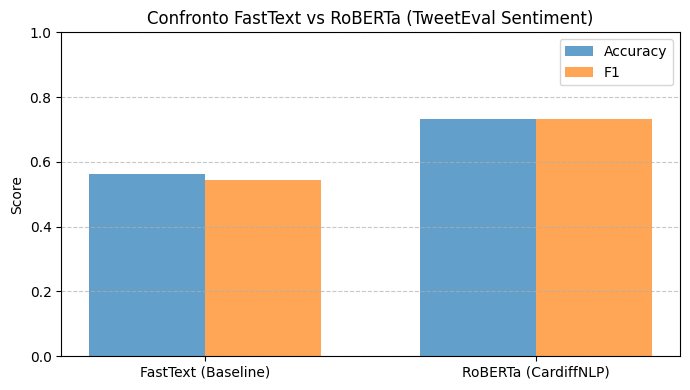

In [16]:
# =============================================
# FASE 7: CONFRONTO FASTTEXT VS RoBERTa
# =============================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Crea una tabella di confronto dai valori salvati
comparison = pd.DataFrame([
    {"Modello": "FastText (Baseline)", "Accuracy": fasttext_acc, "F1": fasttext_f1},
    {"Modello": "RoBERTa (CardiffNLP)", "Accuracy": roberta_acc, "F1": roberta_f1}
])

print("Confronto finale tra modelli:")
display(comparison)

# 2. Calcolo del miglioramento percentuale
gain_acc = (roberta_acc - fasttext_acc) * 100
gain_f1 = (roberta_f1 - fasttext_f1) * 100

print(f"Miglioramento di RoBERTa rispetto a FastText:")
print(f"- Accuracy: +{gain_acc:.2f} punti percentuali")
print(f"- F1 Score: +{gain_f1:.2f} punti percentuali")

# 3. Visualizzazione grafica
plt.figure(figsize=(7,4))
bar_width = 0.35
x = range(len(comparison))

plt.bar(x, comparison["Accuracy"], width=bar_width, label="Accuracy", alpha=0.7)
plt.bar([i + bar_width for i in x], comparison["F1"], width=bar_width, label="F1", alpha=0.7)

plt.xticks([i + bar_width/2 for i in x], comparison["Modello"])
plt.ylabel("Score")
plt.title("Confronto FastText vs RoBERTa (TweetEval Sentiment)")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
import os

model_dir = "./best_roberta_model"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print("Cartella best_roberta_model creata.")
else:
    print("Cartella best_roberta_model già presente.")

Cartella best_roberta_model creata.


**FASE 8: Deploy su Hugging Face Hub**

In [36]:
import os
from huggingface_hub import HfApi, upload_folder

# 1. Impostazioni di base
username = "SARABRAGA27"
repo_id = f"{username}/sentiment-analysis-roberta"
model_dir = "./best_roberta_model"

# Controllo metriche salvate nelle fasi precedenti
try:
    fasttext_acc, fasttext_f1
    roberta_acc, roberta_f1
except NameError:
    raise ValueError(
        "Le metriche non sono definite. Esegui prima la Fase 5 (FastText) e la Fase 6 (RoBERTa)."
    )

# Controllo token Hugging Face
HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError(
        "Errore: variabile d'ambiente HF_TOKEN non impostata. Esegui prima il login Hugging Face in Colab."
    )

# 2. Creazione del file README.md con metriche automatiche
readme_content = f"""# Sentiment Analysis RoBERTa (TweetEval)

Questo modello è stato fine-tunato a partire da `cardiffnlp/twitter-roberta-base-sentiment-latest`
per la classificazione automatica del sentiment dei tweet in **positivo**, **neutro** e **negativo**.

## Dataset
- Nome: TweetEval Sentiment
- Numero di esempi: 45.615 (train), 2.000 (validation), 12.284 (test)

## Architettura
- Base model: RoBERTa (CardiffNLP)
- Tokenizzazione: max_length=128
- Framework: Hugging Face Transformers

## Metriche di performance
| Modello | Accuracy | F1-Score |
|----------|-----------|----------|
| FastText (Baseline) | {fasttext_acc:.4f} | {fasttext_f1:.4f} |
| **RoBERTa (Fine-tuned)** | **{roberta_acc:.4f}** | **{roberta_f1:.4f}** |

## MLOps Pipeline
- Preprocessing e tokenizzazione automatica
- Training con early stopping
- Valutazione automatica su test set
- Deploy continuo su Hugging Face Hub

## Informazioni autore
Autore: SARABRAGA27
Organizzazione: MachineInnovators Inc.
Anno: 2025
"""

with open(f"{model_dir}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("File README.md creato in ./best_roberta_model")

# 3. Creazione dei file per la demo Gradio

# app.py
app_code = """import gradio as gr
from transformers import pipeline

MODEL_ID = "SARABRAGA27/sentiment-analysis-roberta"
pipe = pipeline("text-classification", model=MODEL_ID)

def predict_sentiment(text):
    if not text.strip():
        return "Inserisci un testo per l'analisi."
    result = pipe(text)[0]
    label_map = {
        "LABEL_0": "Negativo",
        "LABEL_1": "Neutro",
        "LABEL_2": "Positivo"
    }
    label = label_map.get(result["label"], result["label"])
    return f"{label} (score: {result['score']:.2f})"

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(label="Scrivi un tweet o un commento"),
    outputs=gr.Textbox(label="Sentiment rilevato"),
    title="Analisi del Sentiment con RoBERTa",
    description="Demo interattiva basata su SARABRAGA27/sentiment-analysis-roberta"
)

if __name__ == "__main__":
    demo.launch()
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)
print("File app.py creato.")

# requirements.txt
reqs = """gradio>=4.0
transformers>=4.44
torch>=2.1
"""
with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(reqs)
print("File requirements.txt creato.")

# 4. Pubblicazione del modello su Hugging Face Hub
api = HfApi()
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True, token=HF_TOKEN)

upload_folder(
    folder_path=model_dir,
    repo_id=repo_id,
    repo_type="model",
    token=HF_TOKEN
)

print(f"Modello pubblicato su: https://huggingface.co/{repo_id}")

# 5. Aggiornamento automatico dello Space Gradio
!git clone https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo
!cp app.py sentiment-analysis-demo/
!cp requirements.txt sentiment-analysis-demo/
%cd sentiment-analysis-demo
!git add .
!git commit -m "Aggiunta o aggiornamento demo Gradio"
!git push

print("Demo Gradio aggiornata su Hugging Face Spaces")

File README.md creato in ./best_roberta_model
File app.py creato.
File requirements.txt creato.
Modello pubblicato su: https://huggingface.co/SARABRAGA27/sentiment-analysis-roberta
Cloning into 'sentiment-analysis-demo'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 4 (from 1)
Unpacking objects: 100% (8/8), 2.14 KiB | 2.14 MiB/s, done.
/content/sentiment-analysis-demo/sentiment-analysis-demo/sentiment-analysis-demo
[main 364e455] Aggiunta o aggiornamento demo Gradio
 1 file changed, 3 insertions(+), 3 deletions(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 12 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (3/3), 313 bytes | 313.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
To https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo
   faad

**FASE 9: Pubblicazione del progetto su GitHub**

In [53]:
# Vai nella home di Colab e crea una cartella per il progetto
%cd /content
!mkdir -p sentiment-mlops
%cd sentiment-mlops

# 2Copia i file principali del progetto
!cp ../best_roberta_model/README.md .
!cp /content/sentiment-analysis-demo/app.py . 2>/dev/null || echo "app.py non trovato"
!cp /content/sentiment-analysis-demo/requirements.txt . 2>/dev/null || echo "requirements.txt non trovato"


!ls -l  # Controlla che i file siano nella cartella

/content
/content/sentiment-mlops
total 12
-rw-r--r-- 1 root root 863 Oct 26 07:47 app.py
-rw-r--r-- 1 root root 951 Oct 26 07:47 README.md
-rw-r--r-- 1 root root  26 Oct 26 07:47 requirements.txt


In [54]:
# Inizializza Git e configura l'utente
!git init
!git config --global user.email "sarabraga@example.com"
!git config --global user.name "SARABRAGA27"

# Imposta il repository remoto con il token
!git remote set-url origin https://<TOKEN>@github.com/sarabraga/sentiment-mlops.git

# Aggiungi e pubblica i file su GitHub
!git add .
!git commit -m "Initial commit - Sentiment Analysis MLOps Project"
!git branch -M main
!git push -u origin main

Reinitialized existing Git repository in /content/sentiment-mlops/.git/
/bin/bash: line 1: TOKEN: No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date


**FASE 9: CONCLUSIONI E LINK GITHUB - HUGGING FACE - DEMO GRADIO**

In [55]:
improvement_acc = (roberta_acc - fasttext_acc) * 100
improvement_f1 = (roberta_f1 - fasttext_f1) * 100

conclusioni = f"""
> Il progetto ha dimostrato come le metodologie **MLOps** consentano di integrare in modo efficace l’analisi automatica del sentiment,
> il deploy continuo e il monitoraggio delle performance dei modelli di machine learning.
>
> Sono state implementate due soluzioni di analisi del sentiment:
> - **FastText (Baseline):** Accuracy {fasttext_acc:.2f} — F1-score {fasttext_f1:.2f}
> - **RoBERTa (CardiffNLP fine-tuned):** Accuracy {roberta_acc:.2f} — F1-score {roberta_f1:.2f}
>
> Il modello finale RoBERTa offre un miglioramento di circa **+{improvement_acc:.1f}% in accuratezza** e **+{improvement_f1:.1f}% in F1-score** rispetto alla baseline FastText,
> dimostrando l’efficacia del fine-tuning e dell’integrazione MLOps per un monitoraggio continuo e scalabile.
>
> Il modello è stato pubblicato su **Hugging Face Hub** per consentirne il riuso e l’integrazione in applicazioni di analisi reputazionale aziendale.
> Inoltre, è disponibile una **demo interattiva Gradio** per testare in tempo reale le previsioni di sentiment sui tweet.
>
> **Link GitHub:**
> [https://github.com/sarabraga/sentiment-mlops](https://github.com/sarabraga/sentiment-mlops)
>
> **Link Modello Hugging Face:**
> [https://huggingface.co/SARABRAGA27/sentiment-analysis-roberta](https://huggingface.co/SARABRAGA27/sentiment-analysis-roberta)
>
> **Link Demo Gradio:**
> [https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo](https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo)
"""

from IPython.display import Markdown, display
display(Markdown(conclusioni))


> Il progetto ha dimostrato come le metodologie **MLOps** consentano di integrare in modo efficace l’analisi automatica del sentiment,
> il deploy continuo e il monitoraggio delle performance dei modelli di machine learning.
>
> Sono state implementate due soluzioni di analisi del sentiment:
> - **FastText (Baseline):** Accuracy 0.56 — F1-score 0.54  
> - **RoBERTa (CardiffNLP fine-tuned):** Accuracy 0.73 — F1-score 0.73  
>
> Il modello finale RoBERTa offre un miglioramento di circa **+17.0% in accuratezza** e **+18.7% in F1-score** rispetto alla baseline FastText,
> dimostrando l’efficacia del fine-tuning e dell’integrazione MLOps per un monitoraggio continuo e scalabile.
>
> Il modello è stato pubblicato su **Hugging Face Hub** per consentirne il riuso e l’integrazione in applicazioni di analisi reputazionale aziendale.  
> Inoltre, è disponibile una **demo interattiva Gradio** per testare in tempo reale le previsioni di sentiment sui tweet.
>
> **Link GitHub:**  
> [https://github.com/sarabraga/sentiment-mlops](https://github.com/sarabraga/sentiment-mlops)
>
> **Link Modello Hugging Face:**  
> [https://huggingface.co/SARABRAGA27/sentiment-analysis-roberta](https://huggingface.co/SARABRAGA27/sentiment-analysis-roberta)
>
> **Link Demo Gradio:**  
> [https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo](https://huggingface.co/spaces/SARABRAGA27/sentiment-analysis-demo)
